## 0. Importación de librerías requeridas

Importaremos las librerías `numpy`, `os` y `cv2` para la carga y procesamiento de las imágenes, así como la librería `scikit_learn` para usar los algoritmos de agrupación y la librería `matplotlib` para visualizar las imágenes resultantes:

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth

## 1. Recopilación de un conjunto diverso de imágenes en diferentes estilos artísticos

Recopilación de un conjunto diverso de imágenes en diferentes estilos artísticos (al menos tres estilos o pintores), a partir del repositorio. Al comienzo del notebook se deben mostrar las imágenes seleccionadas (entre 6 – 10 imágenes), explicando, de manera breve, la motivación para su selección.

<h3>Imágenes del conjunto de datos</h3>

<table>
<tr>
<td><img src="imagenes/camille-pissarro_eugene-murer-at-his-pastry-oven-1877.jpg" width="180"></td>
<td><img src="imagenes/frank-stella_giuf-la-luna-i-ladri-e-le-guardie-1984.jpg" width="180"></td>
<td><img src="imagenes/jack-bush_down-and-across-1967.jpg" width="180"></td>
</tr>

<tr>
<td><img src="imagenes/katsushika-hokusai_not_detected_223529.jpg" width="180"></td>
<td><img src="imagenes/katsushika-hokusai_the-fields-of-sekiya-by-the-sumida-river-1831.jpg" width="180"></td>
<td><img src="imagenes/richard-diebenkorn_ocean-park-no-45.jpg" width="180"></td>
</tr>

<tr>
<td><img src="imagenes/theodoros-stamos_what-the-wind-does-1947.jpg" width="180"></td>
<td><img src="imagenes/utagawa-kuniyoshi_tokiwa-gozen-with-her-three-children-in-the-snow.jpg" width="180"></td>
<td><img src="imagenes/winston-churchill_trees-and-shadows(1).jpg" width="180"></td>
</tr>
</table>

Se escogieron estas imagenes ya que cada una es un estilo diferente y tienen bastantes colores, lo que permite ver si el modelo esta realizando una clasificación correcta de los colores, ademas que estas imagenes tienen colores con alto contraste lo que permite ver si la clasificación y creación de la paleta es correcta.

## 2. Preparación de los datos
### 2.1 Carga de los datos 

Las imagenes las almacenamos en una carpeta llamada "imagenes"; posteriromente creamos una funcion `cargar_imagenes()` para la carga de las imágenes de la carpeta y utilizaremos funciones como `imread()` y `cvtColor()` para realizar la carga y procesamiento de cada una:

In [2]:
root_path = 'imagenes'
img_files = os.listdir(root_path)
img_files

['camille-pissarro_eugene-murer-at-his-pastry-oven-1877.jpg',
 'frank-stella_giuf-la-luna-i-ladri-e-le-guardie-1984.jpg',
 'jack-bush_down-and-across-1967.jpg',
 'katsushika-hokusai_not_detected_223529.jpg',
 'katsushika-hokusai_the-fields-of-sekiya-by-the-sumida-river-1831.jpg',
 'richard-diebenkorn_ocean-park-no-45.jpg',
 'theodoros-stamos_what-the-wind-does-1947.jpg',
 'utagawa-kuniyoshi_tokiwa-gozen-with-her-three-children-in-the-snow.jpg',
 'winston-churchill_trees-and-shadows(1).jpg']

In [3]:
def cargar_imagenes(root_path, file_names):
    image_list = list()
    for file in file_names:
        img = cv2.imread(os.path.join(root_path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image_list.append(img)
    return image_list

Creamos una funcion que nos permite normalizar la imagen, prepararemos las imágenes como una lista de píxeles, normalizando sus valores para que estén en el rango [0, 1]. Este será el conjunto de datos que utilizaremos para el entrenamiento de los modelos. La cual luego usaremos en el Pipeline

In [4]:
def preparar_imagen(img):
    img = img.reshape((-1, 3))
    img = img / 255.0
    return img

Cargamos las imagenes originales sin modificaciones para despues ser utilizadas en el modelo generado

In [5]:
img_original = cargar_imagenes(root_path, img_files)
img_original

[array([[[ 54,  54,  54],
         [ 58,  58,  58],
         [ 61,  61,  61],
         ...,
         [112, 109,  94],
         [215, 213, 200],
         [219, 221, 208]],
 
        [[ 65,  65,  65],
         [ 64,  64,  64],
         [ 62,  62,  62],
         ...,
         [115, 112,  97],
         [219, 217, 204],
         [225, 227, 214]],
 
        [[ 62,  62,  62],
         [ 62,  62,  62],
         [ 62,  62,  62],
         ...,
         [109, 106,  91],
         [213, 211, 198],
         [219, 221, 208]],
 
        ...,
 
        [[248, 250, 247],
         [250, 252, 249],
         [250, 252, 249],
         ...,
         [243, 251, 253],
         [240, 249, 248],
         [242, 252, 251]],
 
        [[246, 255, 252],
         [242, 251, 248],
         [238, 247, 244],
         ...,
         [243, 251, 253],
         [244, 254, 255],
         [245, 255, 254]],
 
        [[236, 238, 233],
         [238, 240, 235],
         [240, 242, 239],
         ...,
         [248, 252, 251],
  

## 3. Construcción del pipeline de preparación de datos.

In [6]:
def crear_pipeline(num_clusters):
    pipeline = Pipeline([
        ('preparacion', FunctionTransformer(preparar_imagen)),
        ('modelo', KMeans(n_clusters=num_clusters,random_state=42))
    ])
    
    return pipeline

## 4. Construcción del modelo de agrupación con el algoritmo seleccionado con búsqueda de hiperparámetros,.

Como se requiere que el numero de los grupos sea dinamico usamos el metodo de la silueta para obtener cual es el mejor K 

In [7]:
def seleccionar_k(img, k_min=3, k_max=20, muestra=5000):
    pixels = preparar_imagen(img)
    # Tomar muestra aleatoria para que sea más rápido
    np.random.seed(42)
    indices = np.random.choice(
        len(pixels),
        size=min(muestra, len(pixels)),
        replace=False
    )
    pixels_muestra = pixels[indices]

    mejor_k = None
    mejor_score = -1
    
    for k in range(k_min, k_max + 1):
        modelo = KMeans(
            n_clusters=k,
            random_state=42
        )
        labels = modelo.fit_predict(pixels_muestra)

        score = silhouette_score(
            pixels_muestra,
            labels
        )
        print(f"K={k} - Silhouette Score={score:.4f}")

        if score > mejor_score:
            mejor_score = score
            mejor_k = k

    print(f"\nMejor número de grupos: {mejor_k}")
    
    return mejor_k

In [8]:
num_clusters = seleccionar_k(img_original[5])

K=3 - Silhouette Score=0.5437
K=4 - Silhouette Score=0.5646
K=5 - Silhouette Score=0.5688
K=6 - Silhouette Score=0.5302
K=7 - Silhouette Score=0.5075
K=8 - Silhouette Score=0.4806
K=9 - Silhouette Score=0.4606
K=10 - Silhouette Score=0.4326
K=11 - Silhouette Score=0.4430
K=12 - Silhouette Score=0.4372
K=13 - Silhouette Score=0.4359
K=14 - Silhouette Score=0.4085
K=15 - Silhouette Score=0.3967
K=16 - Silhouette Score=0.3829
K=17 - Silhouette Score=0.3681
K=18 - Silhouette Score=0.3600
K=19 - Silhouette Score=0.3575
K=20 - Silhouette Score=0.3568

Mejor número de grupos: 5


## KMeans

En esta versión, primero debemos especificar el número de clústeres. Por ejemplo, realizaremos una segmentación con cinco clústeres:

In [9]:
pipeline = crear_pipeline(num_clusters)
pipeline.fit(img_original[5])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1382
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...001C79BB1B880>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [10]:
kmeans_model = pipeline.named_steps['modelo']
labels = kmeans_model.labels_
centroids = kmeans_model.cluster_centers_


Podemos ver la paleta de colores resultante como los centroides encontrados por el modelo:

In [11]:
counts = np.bincount(labels)
# Ordenar colores de mayor a menor frecuencia
sorted_idx = np.argsort(counts)[::-1]
centroids = centroids[sorted_idx]
counts = counts[sorted_idx]

# Convertir centroides a enteros
centroids = (centroids * 255).astype(np.uint8)


## 5.Construcción de la función que transforma los grupos de colores identificados en un muestrario representativo

In [12]:
def crear_paleta(colors, counts, width=600, height=120):
    paleta = np.zeros((height, width, 3), dtype=np.uint8)
    
    total = counts.sum()
    start_x = 0
    
    for color, count in zip(colors, counts):
        end_x = start_x + int((count / total) * width)
        paleta[:, start_x:end_x, :] = color
        start_x = end_x

    return paleta

In [13]:
paleta_final = crear_paleta(centroids, counts)

## 6. Evidencia del desempeño del método construido mostrando la paleta generada para al menos cuatro (4) imágenes de diferentes estilos, con la visualización de la distribución de colores en el espacio de dos dimensiones.

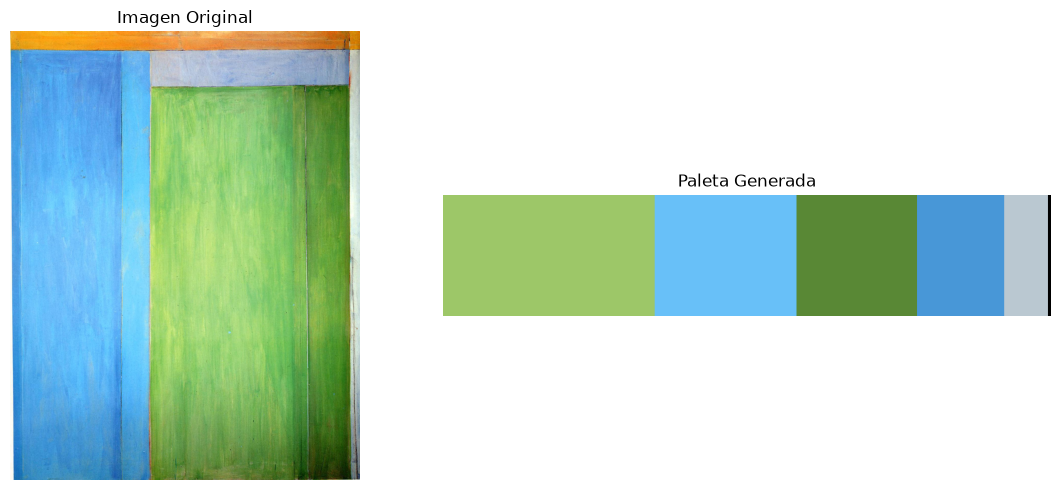

In [14]:
plt.figure(figsize=(12, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_original[5])
plt.axis('off')

# Paleta generada
plt.subplot(1, 2, 2)
plt.title('Paleta Generada')
plt.imshow(paleta_final)
plt.axis('off')

plt.tight_layout()
plt.show()

Y podemos generar una máscara o imagen segmentada con la expresión `centroids[labels]`. Ten en cuenta que, para visualizar la imagen correctamente, reescalamos los valores de píxeles al rango original de [0, 255], y volvemos a las dimensiones originales con `reshape()`:

In [15]:
def procesar_imagen(img):

    # 1. Buscar automáticamente el mejor número de clusters
    num_clusters = seleccionar_k(img)

    # 2. Crear el pipeline
    pipeline = crear_pipeline(num_clusters)

    # 3. Entrenar KMeans
    pipeline.fit(img)

    # 4. Obtener KMeans del pipeline
    kmeans_model = pipeline.named_steps['modelo']

    labels = kmeans_model.labels_
    centroids = kmeans_model.cluster_centers_

    # 5. Contar cuántos píxeles hay en cada grupo
    counts = np.bincount(labels)

    # 6. Ordenar colores de mayor a menor frecuencia
    orden = np.argsort(counts)[::-1]

    centroids = centroids[orden]
    counts = counts[orden]

    # 7. Volver de 0-1 a 0-255
    centroids = (centroids * 255).astype(np.uint8)

    # 8. Crear paleta
    paleta = crear_paleta(centroids, counts)

    return paleta, num_clusters

In [16]:
img_original

[array([[[ 54,  54,  54],
         [ 58,  58,  58],
         [ 61,  61,  61],
         ...,
         [112, 109,  94],
         [215, 213, 200],
         [219, 221, 208]],
 
        [[ 65,  65,  65],
         [ 64,  64,  64],
         [ 62,  62,  62],
         ...,
         [115, 112,  97],
         [219, 217, 204],
         [225, 227, 214]],
 
        [[ 62,  62,  62],
         [ 62,  62,  62],
         [ 62,  62,  62],
         ...,
         [109, 106,  91],
         [213, 211, 198],
         [219, 221, 208]],
 
        ...,
 
        [[248, 250, 247],
         [250, 252, 249],
         [250, 252, 249],
         ...,
         [243, 251, 253],
         [240, 249, 248],
         [242, 252, 251]],
 
        [[246, 255, 252],
         [242, 251, 248],
         [238, 247, 244],
         ...,
         [243, 251, 253],
         [244, 254, 255],
         [245, 255, 254]],
 
        [[236, 238, 233],
         [238, 240, 235],
         [240, 242, 239],
         ...,
         [248, 252, 251],
  

In [17]:
paletas = []
clusters = []

for i in range(len(img_original)):

    print(f"\nProcesando imagen {i + 1} de {len(img_original)}")

    paleta, num_clusters = procesar_imagen(img_original[i])

    paletas.append(paleta)
    clusters.append(num_clusters)


Procesando imagen 1 de 9
K=3 - Silhouette Score=0.5665
K=4 - Silhouette Score=0.5057
K=5 - Silhouette Score=0.4668
K=6 - Silhouette Score=0.4737
K=7 - Silhouette Score=0.4274
K=8 - Silhouette Score=0.3932
K=9 - Silhouette Score=0.3879
K=10 - Silhouette Score=0.3921
K=11 - Silhouette Score=0.3624
K=12 - Silhouette Score=0.3594
K=13 - Silhouette Score=0.3352
K=14 - Silhouette Score=0.3452
K=15 - Silhouette Score=0.3554
K=16 - Silhouette Score=0.3499
K=17 - Silhouette Score=0.3432
K=18 - Silhouette Score=0.3425
K=19 - Silhouette Score=0.3408
K=20 - Silhouette Score=0.3383

Mejor número de grupos: 3

Procesando imagen 2 de 9
K=3 - Silhouette Score=0.3753
K=4 - Silhouette Score=0.4461
K=5 - Silhouette Score=0.4822
K=6 - Silhouette Score=0.4681
K=7 - Silhouette Score=0.4483
K=8 - Silhouette Score=0.4132
K=9 - Silhouette Score=0.3863
K=10 - Silhouette Score=0.3705
K=11 - Silhouette Score=0.3746
K=12 - Silhouette Score=0.3829
K=13 - Silhouette Score=0.3828
K=14 - Silhouette Score=0.3810
K=15 

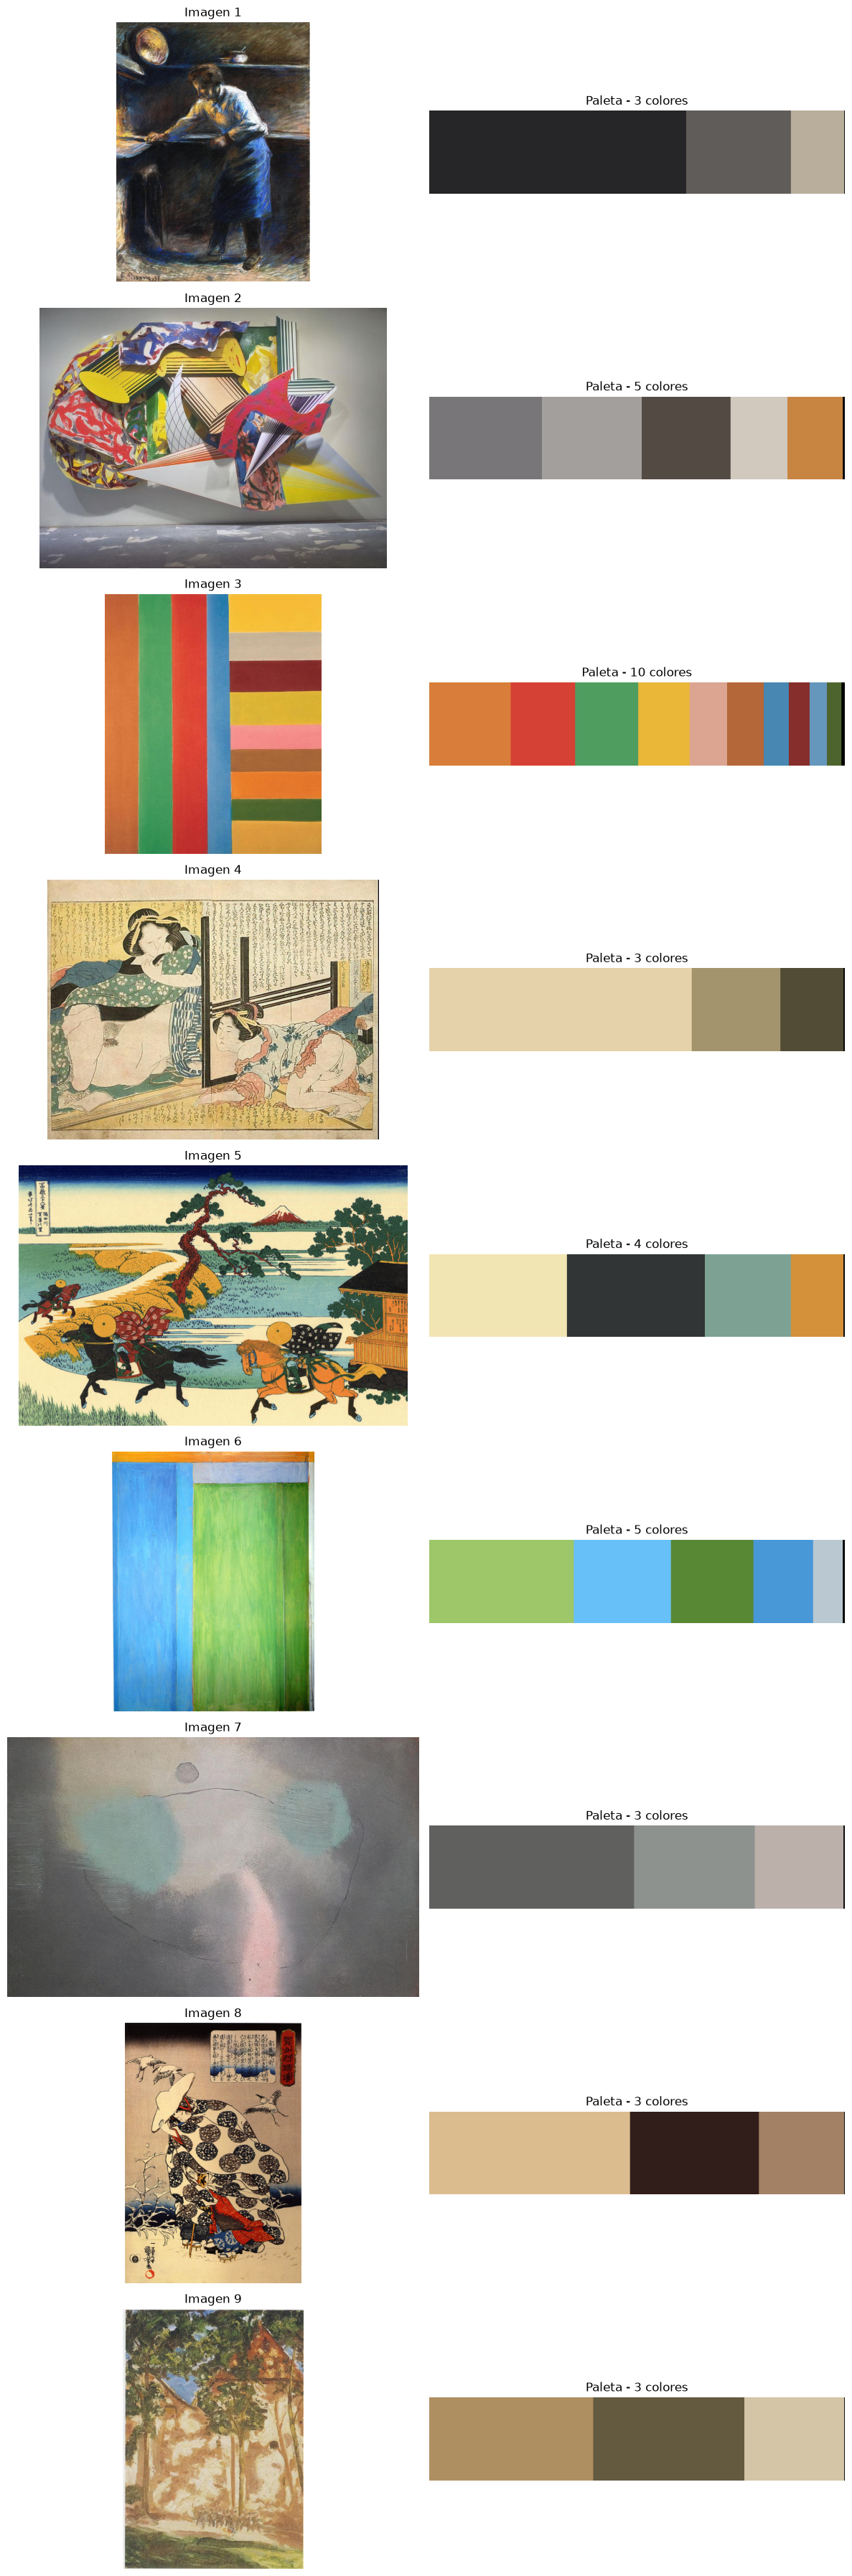

In [18]:
n = len(img_original)

plt.figure(figsize=(12, 4 * n))

for i in range(n):

    # Imagen original
    plt.subplot(n, 2, i * 2 + 1)
    plt.imshow(img_original[i])
    plt.title(f'Imagen {i + 1}')
    plt.axis('off')

    # Paleta
    plt.subplot(n, 2, i * 2 + 2)
    plt.imshow(paletas[i])
    plt.title(f'Paleta - {clusters[i]} colores')
    plt.axis('off')

plt.tight_layout()
plt.show()